In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from scipy.stats import ttest_ind

In [2]:
df = pd.read_csv("QVI_data.csv")

In [3]:
df.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [4]:
df.columns

Index(['LYLTY_CARD_NBR', 'DATE', 'STORE_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE', 'BRAND', 'LIFESTAGE',
       'PREMIUM_CUSTOMER'],
      dtype='str')

In [5]:
df['DATE'] = pd.to_datetime(df['DATE'])

In [6]:
df['MONTH_ID'] = (
    df['DATE']
    .dt.strftime('%Y%m')
)

In [7]:
df[['DATE', 'MONTH_ID']].head()

,DATE,MONTH_ID
0,2018-10-17,201810
1,2018-09-16,201809
2,2019-03-07,201903
3,2019-03-08,201903
4,2018-11-02,201811


In [8]:
monthly_metrics = df.groupby(
    ['STORE_NBR', 'MONTH_ID']
).agg({
    'TOT_SALES':'sum',
    'LYLTY_CARD_NBR':'nunique',
    'TXN_ID':'nunique'
}).reset_index()

In [9]:
monthly_metrics.rename(
    columns={
        'LYLTY_CARD_NBR':
        'TOTAL_CUSTOMERS',

        'TXN_ID':
        'TOTAL_TXNS'
    },
    inplace=True
)

In [10]:
monthly_metrics[
    'TXN_PER_CUSTOMER'
] = (
    monthly_metrics[
        'TOTAL_TXNS'
    ]
    /
    monthly_metrics[
        'TOTAL_CUSTOMERS'
    ]
)

In [11]:
monthly_metrics.head()

,STORE_NBR,MONTH_ID,TOT_SALES,TOTAL_CUSTOMERS,TOTAL_TXNS,TXN_PER_CUSTOMER
0,1,201807,206.9,49,52,1.061224
1,1,201808,176.1,42,43,1.023810
2,1,201809,278.8,59,62,1.050847
3,1,201810,188.1,44,45,1.022727
4,1,201811,192.6,46,47,1.021739


In [12]:
trial_stores = [77, 86, 88]

In [13]:
pre_trial = monthly_metrics[
    monthly_metrics[
        'MONTH_ID'
    ] < '201902'
]

In [ ]:
def find_control_store(trial_store):

    trial_data = pre_trial[
        pre_trial['STORE_NBR']
        == trial_store
    ]

    correlations = {}

    for store in pre_trial[
        'STORE_NBR'
    ].unique():

        if store == trial_store:
            continue

        control_data = pre_trial[
            pre_trial['STORE_NBR']
            == store
        ]

        merged_df = pd.merge(
            trial_data,
            control_data,
            on='MONTH_ID',
            suffixes=(
                '_trial',
                '_control'
            )
        )

        # Skip stores with too little data
        if len(merged_df) < 3:
            continue

        try:

            sales_corr = merged_df[
                'TOT_SALES_trial'
            ].corr(
                merged_df[
                    'TOT_SALES_control'
                ]
            )

            cust_corr = merged_df[
                'TOTAL_CUSTOMERS_trial'
            ].corr(
                merged_df[
                    'TOTAL_CUSTOMERS_control'
                ]
            )

            txn_corr = merged_df[
                'TXN_PER_CUSTOMER_trial'
            ].corr(
                merged_df[
                    'TXN_PER_CUSTOMER_control'
                ]
            )

            avg_corr = np.nanmean([
                sales_corr,
                cust_corr, 
                txn_corr
            ])

            if not np.isnan(avg_corr):
                correlations[
                    store
                ] = avg_corr

        except:
            continue

    best_store = max(
        correlations,
        key=correlations.get
    )

    return best_store

In [15]:
for store in trial_stores:
    control = find_control_store(store)

    print(
        f"Trial Store {store}"
        f" → Control Store {control}"
    )

c:\Users\Krish\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Krish\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Trial Store 77 → Control Store 119
Trial Store 86 → Control Store 138
Trial Store 88 → Control Store 14


In [16]:
def compare_store(
    trial_store,
    control_store
):

    compare = monthly_metrics[
        monthly_metrics[
            'STORE_NBR'
        ].isin(
            [
                trial_store,
                control_store
            ]
        )
    ]

    plt.figure(
        figsize=(12,6)
    )

    sns.lineplot(
        data=compare,
        x='MONTH_ID',
        y='TOT_SALES',
        hue='STORE_NBR',
        marker='o'
    )

    plt.title(
        f"Trial {trial_store}"
        f" vs Control "
        f"{control_store}"
    )

    plt.xticks(
        rotation=45
    )

    plt.show()

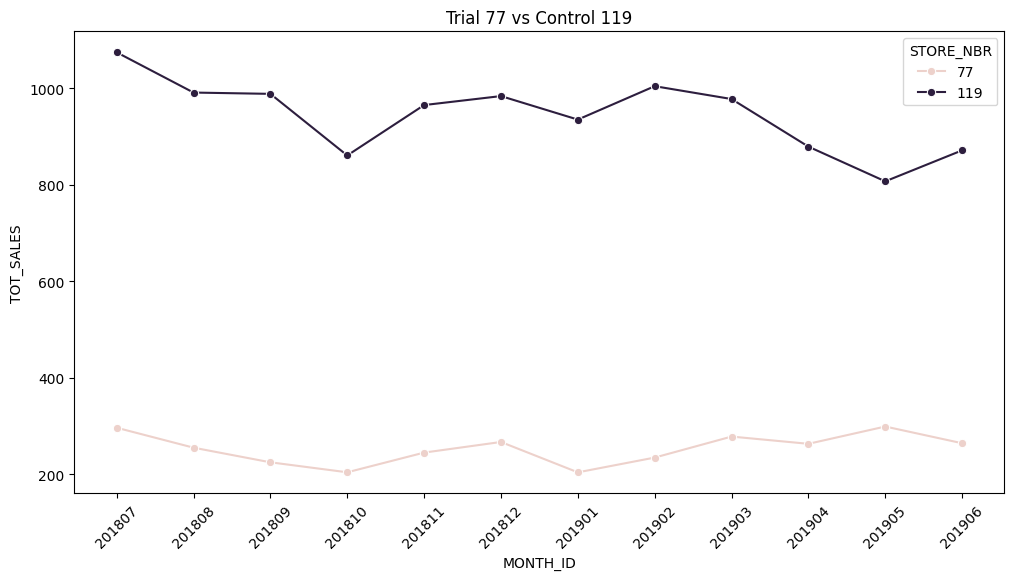

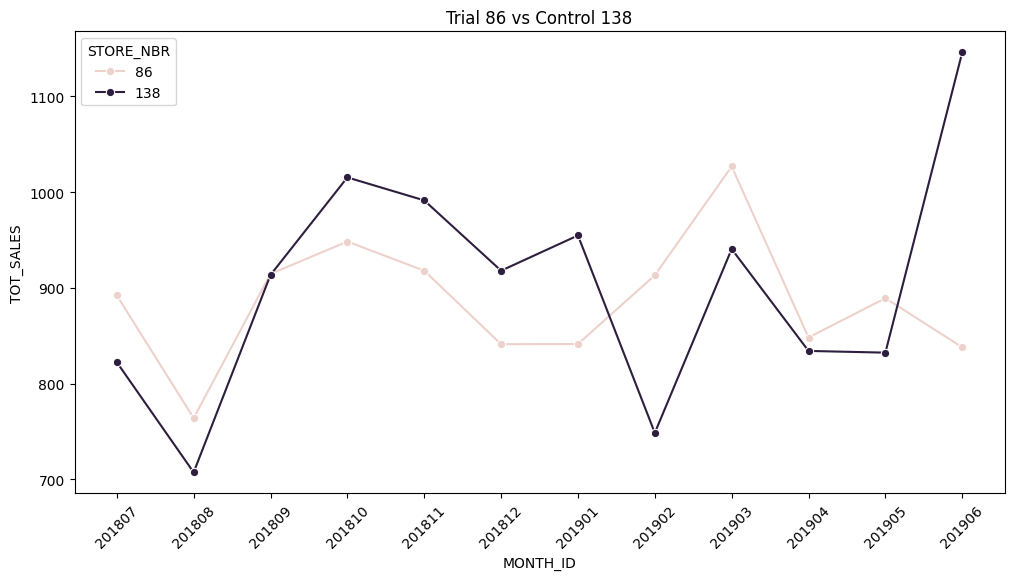

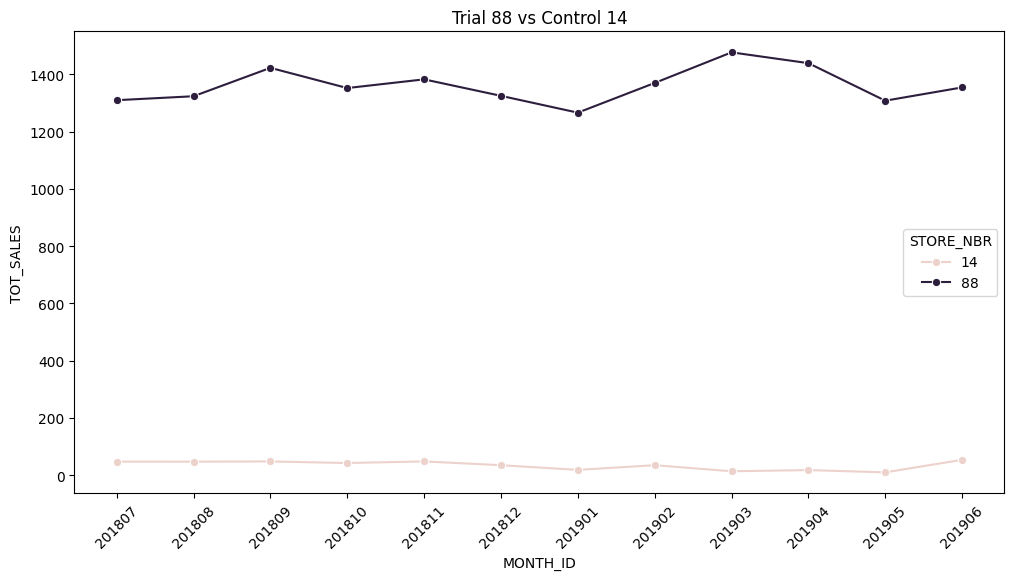

In [17]:
compare_store(77, 119)
compare_store(86, 138)
compare_store(88, 14)

In [18]:
trial_period = monthly_metrics[
    (
        monthly_metrics[
            'MONTH_ID'
        ] >= '201902'
    )
    &
    (
        monthly_metrics[
            'MONTH_ID'
        ] <= '201904'
    )
]

In [19]:
def sales_test(
    trial_store,
    control_store
):

    trial_sales = trial_period[
        trial_period[
            'STORE_NBR'
        ] == trial_store
    ][
        'TOT_SALES'
    ]

    control_sales = trial_period[
        trial_period[
            'STORE_NBR'
        ] == control_store
    ][
        'TOT_SALES'
    ]

    t_stat, p_val = ttest_ind(
        trial_sales,
        control_sales
    )

    print(
        f"Store {trial_store}"
    )

    print(
        f"P-value: {p_val}"
    )

    if p_val < 0.05:

        print(
            "Significant difference"
        )

    else:

        print(
            "No significant difference"
        )

In [20]:
sales_test(77, 119)
sales_test(86, 138)
sales_test(88, 14)

Store 77
P-value: 6.55567166567031e-05
Significant difference
Store 86
P-value: 0.311216429465881
No significant difference
Store 88
P-value: 1.5972986604225574e-06
Significant difference


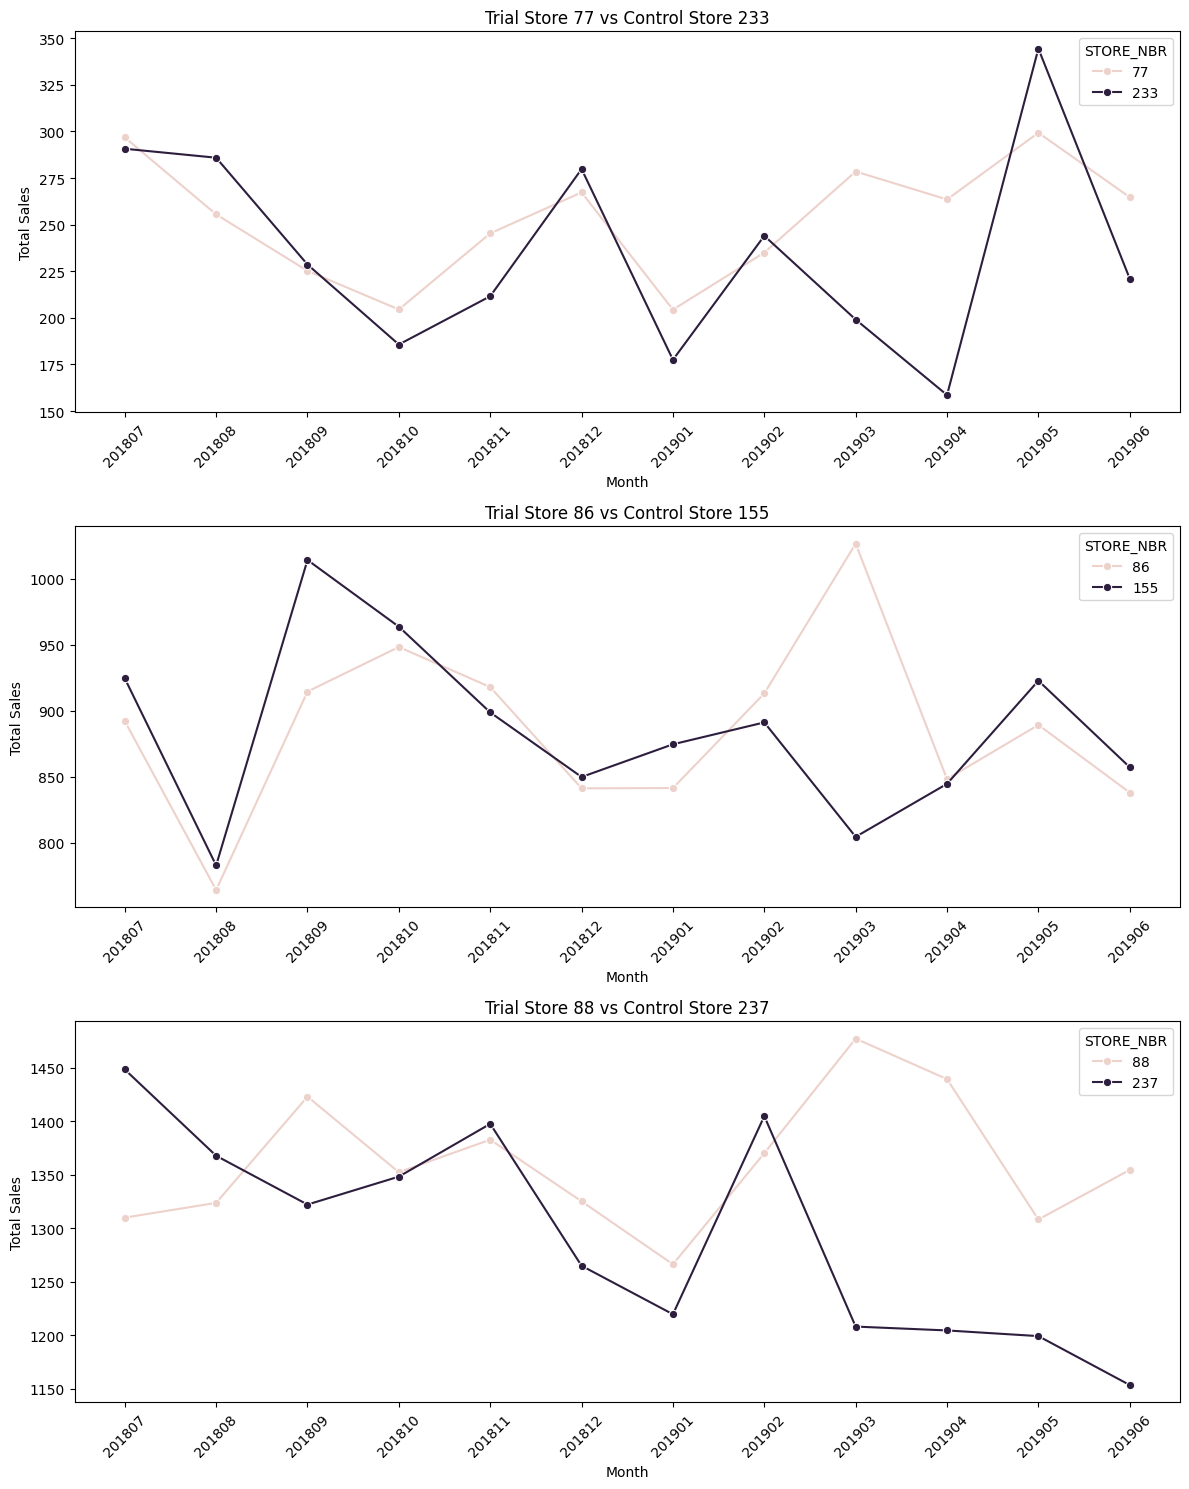

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Replace with your actual control stores
control_77 = 233
control_86 = 155
control_88 = 237

store_pairs = [
    (77, control_77),
    (86, control_86),
    (88, control_88)
]

fig, axes = plt.subplots(
    3, 1,
    figsize=(12, 15)
)

for i, (trial, control) in enumerate(store_pairs):

    compare = monthly_metrics[
        monthly_metrics['STORE_NBR']
        .isin([trial, control])
    ]

    sns.lineplot(
        data=compare,
        x='MONTH_ID',
        y='TOT_SALES',
        hue='STORE_NBR',
        marker='o',
        ax=axes[i]
    )

    axes[i].set_title(
        f'Trial Store {trial} vs Control Store {control}'
    )

    axes[i].tick_params(
        axis='x',
        rotation=45
    )

    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('Total Sales')

plt.tight_layout()
plt.show()